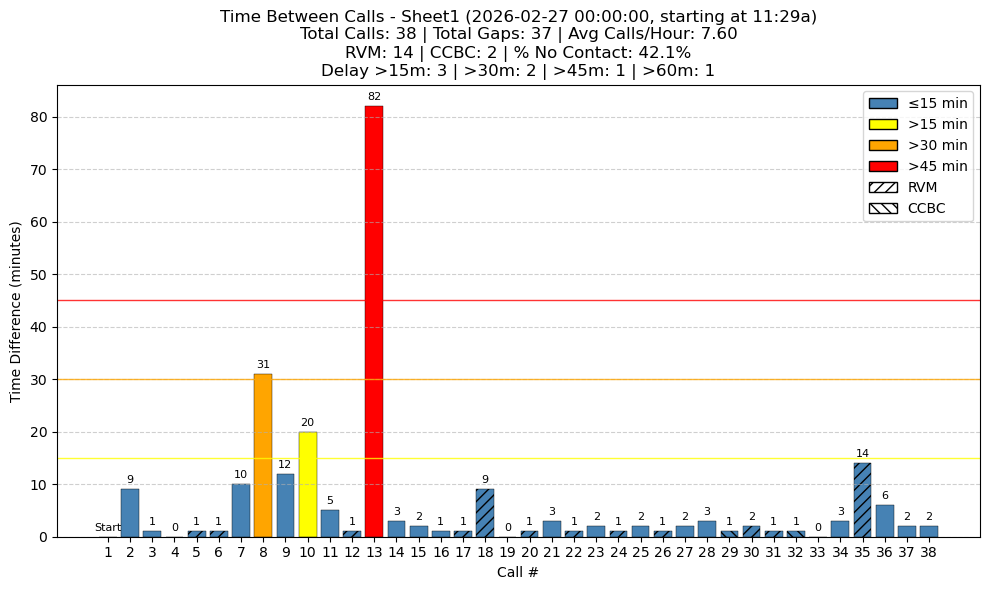

In [7]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FILEPATH = '/Users/robertwrobel/Downloads/kg23.xlsx'

df_dict = pd.read_excel(FILEPATH, sheet_name=None)

def parse_time(val):
    if pd.isna(val):
        return pd.NaT

    s = str(val).strip().lower()

    if re.match(r"^\d{1,2}:\d{2}[ap]$", s):
        s = s + "m"

    if re.match(r"^\d{1,2}:\d{2}(am|pm)$", s):
        return datetime.strptime(s, "%I:%M%p")

    return pd.NaT

def contains_token(block, token):
    as_str = block.astype(str)
    return as_str.apply(lambda col: col.str.contains(token, case=False, na=False)).any().any()

def bar_style(delay_minutes, call_type):
    if pd.isna(delay_minutes):
        color = "lightgray"
    elif delay_minutes > 45:
        color = "red"
    elif delay_minutes > 30:
        color = "orange"
    elif delay_minutes > 15:
        color = "yellow"
    else:
        color = "steelblue"

    if call_type == "rvm":
        hatch = "///"
    elif call_type == "ccbc":
        hatch = "\\\\\\"
    else:
        hatch = None

    return color, hatch

for sheet_name, df in df_dict.items():

    meta = pd.read_excel(
        FILEPATH,
        sheet_name=sheet_name,
        header=None,
        usecols="E",
        nrows=3
    )
    date_label = meta.iloc[1, 0]   # E2
    start_time = meta.iloc[2, 0]   # E3

    if isinstance(date_label, pd.Timestamp):
        date_label = date_label.strftime("%Y-%m-%d")
    else:
        date_label = str(date_label).strip()

    if isinstance(start_time, pd.Timestamp):
        start_time = start_time.strftime("%I:%M %p")
    else:
        start_time = str(start_time).strip()

    for col in df.columns:
        if df[col].dtype == "object":
            df[col] = df[col].astype(str).str.strip()

    records = []
    block_size = 6

    for start in range(0, len(df), block_size):
        block = df.iloc[start:start + block_size].copy()
        if len(block) < 2:
            continue

        updated_val = block.iloc[1].get("Updated", np.nan)
        t = parse_time(updated_val)
        if pd.isna(t):
            continue

        is_rvm = contains_token(block, "rvm")
        is_ccbc = contains_token(block, "ccbc")

        if is_rvm and is_ccbc:
            call_type = "rvm"   
        elif is_rvm:
            call_type = "rvm"
        elif is_ccbc:
            call_type = "ccbc"
        else:
            call_type = "other"

        records.append({
            "CallNum": len(records) + 1,
            "Time": t,
            "CallType": call_type
        })

    calls = pd.DataFrame(records)

    if calls.empty:
        print(f"{sheet_name}: No call times found to plot.")
        continue

    calls["DelayMinutes"] = calls["Time"].diff().dt.total_seconds() / 60
    calls.loc[calls.index[0], "DelayMinutes"] = np.nan

    total_calls = len(calls)
    total_delays = calls["DelayMinutes"].notna().sum()

    rvm_count = (calls["CallType"] == "rvm").sum()
    ccbc_count = (calls["CallType"] == "ccbc").sum()
    nc_count = rvm_count + ccbc_count
    pct_no_contact = (nc_count / total_calls) if total_calls else 0

    delay_15 = (calls["DelayMinutes"] > 15).sum()
    delay_30 = (calls["DelayMinutes"] > 30).sum()
    delay_45 = (calls["DelayMinutes"] > 45).sum()
    delay_60 = (calls["DelayMinutes"] > 60).sum()

    calls["Hour"] = calls["Time"].dt.hour
    call_counts_per_hour = calls.groupby("Hour").size()
    total_hours = call_counts_per_hour.size
    avg_calls_per_hour = total_calls / total_hours if total_hours > 0 else 0

    fig, ax = plt.subplots(figsize=(10, 6))

    for _, row in calls.iterrows():
        color, hatch = bar_style(row["DelayMinutes"], row["CallType"])

        height = row["DelayMinutes"]
        bar = ax.bar(
            row["CallNum"],
            0 if pd.isna(height) else height,
            color=color,
            hatch=hatch,
            edgecolor="black",
            linewidth=0.3
        )[0]

        if not pd.isna(height):
            label = f"{int(round(height))}"
            ax.annotate(
                label,
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8
            )
        else:
            ax.annotate(
                "Start",
                xy=(bar.get_x() + bar.get_width() / 2, 0),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.axhline(15, color="yellow", linewidth=1, alpha=0.8)
    ax.axhline(30, color="orange", linewidth=1, alpha=0.8)
    ax.axhline(45, color="red", linewidth=1, alpha=0.8)

    ax.set_xlabel("Call #")
    ax.set_ylabel("Time Difference (minutes)")
    ax.set_title(
        f"Time Between Calls - {sheet_name} ({date_label}, starting at {start_time})\n"
        f"Total Calls: {total_calls} | Total Gaps: {total_delays} | Avg Calls/Hour: {avg_calls_per_hour:.2f}\n"
        f"RVM: {rvm_count} | CCBC: {ccbc_count} | % No Contact: {pct_no_contact:.1%}\n"
        f"Delay >15m: {delay_15} | >30m: {delay_30} | >45m: {delay_45} | >60m: {delay_60}"
    )

    ax.set_xticks(calls["CallNum"])
    ax.grid(axis="y", linestyle="--", alpha=0.6)

    legend_elements = [
        Patch(facecolor="steelblue", edgecolor="black", label="≤15 min"),
        Patch(facecolor="yellow", edgecolor="black", label=">15 min"),
        Patch(facecolor="orange", edgecolor="black", label=">30 min"),
        Patch(facecolor="red", edgecolor="black", label=">45 min"),
        Patch(facecolor="white", edgecolor="black", hatch="///", label="RVM"),
        Patch(facecolor="white", edgecolor="black", hatch="\\\\\\", label="CCBC"),
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.show()
